In [1]:
# ================================================
# NEPAL ECONOMIC EARLY WARNING SYSTEM
# Notebook: 02_data_collection.ipynb
# Week 2: Fetch macroeconomic data for Nepal
# ================================================

import wbgapi as wb        # World Bank API
import pandas as pd        # data manipulation
import numpy as np         # numerical computing
import matplotlib.pyplot as plt   # plotting
import seaborn as sns      # better charts
import warnings
warnings.filterwarnings('ignore')

# Professional chart style
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All imports successful!")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  wbgapi  : {wb.__version__}")

✅ All imports successful!
  pandas  : 2.3.3
  numpy   : 2.2.5
  wbgapi  : 1.0.14


In [2]:
# ================================================
# STEP 1: Define which indicators to fetch
# World Bank codes → our readable column names
# ================================================

NEPAL_INDICATORS = {
    # --- Core Economic Health ---
    'NY.GDP.MKTP.KD.ZG'    : 'gdp_growth',
    # GDP growth rate (%) — THE main indicator
    # Positive = economy growing, Negative = recession

    'FP.CPI.TOTL.ZG'       : 'inflation',
    # Consumer Price Index growth (%)
    # High inflation = cost of living rising fast

    'SL.UEM.TOTL.ZS'       : 'unemployment',
    # Unemployment rate (%)
    # Rises AFTER a recession starts (lagging indicator)

    # --- Nepal-Specific (CRUCIAL) ---
    'BX.TRF.PWKR.DT.GD.ZS' : 'remittances_pct_gdp',
    # Remittances as % of GDP
    # Nepal-unique: ~25% of GDP comes from abroad
    # A drop here = serious economic stress signal

    'BN.CAB.XOKA.GD.ZS'    : 'current_account_gdp',
    # Current account balance as % of GDP
    # Negative = Nepal importing more than exporting

    'FI.RES.TOTL.MO'       : 'forex_reserves_months',
    # Foreign exchange reserves in months of imports
    # Below 6 months = danger zone for Nepal

    # --- Investment & Consumption ---
    'NE.GDI.TOTL.ZS'       : 'gross_investment_gdp',
    # Gross investment as % of GDP
    # Falls before recessions

    'NE.CON.PRVT.KD.ZG'    : 'consumption_growth',
    # Private consumption growth (%)
    # When people stop spending = economy slowing

    # --- External Sector ---
    'NE.EXP.GNFS.ZS'       : 'exports_pct_gdp',
    # Exports as % of GDP

    'NE.IMP.GNFS.ZS'       : 'imports_pct_gdp',
    # Imports as % of GDP
    # Nepal always imports more than it exports
}

# India indicators — Nepal's economy mirrors India's
INDIA_INDICATORS = {
    'NY.GDP.MKTP.KD.ZG'    : 'india_gdp_growth',
    'FP.CPI.TOTL.ZG'       : 'india_inflation',
}

print(f"✅ Defined {len(NEPAL_INDICATORS)} Nepal indicators")
print(f"✅ Defined {len(INDIA_INDICATORS)} India spillover indicators")
print("\nNepal indicators:")
for code, name in NEPAL_INDICATORS.items():
    print(f"  {name:<30} ← {code}")

✅ Defined 10 Nepal indicators
✅ Defined 2 India spillover indicators

Nepal indicators:
  gdp_growth                     ← NY.GDP.MKTP.KD.ZG
  inflation                      ← FP.CPI.TOTL.ZG
  unemployment                   ← SL.UEM.TOTL.ZS
  remittances_pct_gdp            ← BX.TRF.PWKR.DT.GD.ZS
  current_account_gdp            ← BN.CAB.XOKA.GD.ZS
  forex_reserves_months          ← FI.RES.TOTL.MO
  gross_investment_gdp           ← NE.GDI.TOTL.ZS
  consumption_growth             ← NE.CON.PRVT.KD.ZG
  exports_pct_gdp                ← NE.EXP.GNFS.ZS
  imports_pct_gdp                ← NE.IMP.GNFS.ZS


In [3]:
print("📥 Connecting to World Bank API...")

nepal_raw = wb.data.DataFrame(
    list(NEPAL_INDICATORS.keys()),
    'NPL',
    mrv=60
)

nepal_df = nepal_raw.T

# Rename columns
nepal_df.columns = list(NEPAL_INDICATORS.values())

# FIX: World Bank returns years as 'YR1966', 'YR1967' etc.
# Strip the 'YR' prefix and convert to integer year, then datetime
nepal_df.index = nepal_df.index.str.replace('YR', '', regex=False)
nepal_df.index = pd.to_datetime(nepal_df.index, format='%Y')

nepal_df = nepal_df.sort_index()

print("✅ Nepal data fetched successfully!")
print(f"   Shape: {nepal_df.shape[0]} years × {nepal_df.shape[1]} indicators")
print(f"   From: {nepal_df.index[0].year} → {nepal_df.index[-1].year}")
print("\n--- First 5 rows ---")
print(nepal_df.head().round(2).to_string())

📥 Connecting to World Bank API...
✅ Nepal data fetched successfully!
   Shape: 60 years × 10 indicators
   From: 1966 → 2025

--- First 5 rows ---
            gdp_growth  inflation  unemployment  remittances_pct_gdp  current_account_gdp  forex_reserves_months  gross_investment_gdp  consumption_growth  exports_pct_gdp  imports_pct_gdp
1966-01-01         NaN        NaN           NaN                14.39                  NaN                   5.64                  4.83                8.76             7.04              NaN
1967-01-01         NaN        NaN           NaN                -2.81                  NaN                   6.87                  4.99                6.95            -1.57              NaN
1968-01-01         NaN        NaN           NaN                 1.18                  NaN                   6.85                  5.69                7.50             0.68              NaN
1969-01-01         NaN        NaN           NaN                 4.06                  NaN        

In [4]:
print("=== RECENT DATA (last 10 years) ===")
print(nepal_df.tail(10).round(2).to_string())

print("\n=== MISSING VALUES PER COLUMN ===")
for col in nepal_df.columns:
    total = len(nepal_df)
    missing = nepal_df[col].isna().sum()
    filled = total - missing
    pct = (filled / total * 100)
    bar = "█" * int(pct / 10)
    print(f"  {col:<30} {filled:>3}/{total} filled ({pct:.0f}%) {bar}")

=== RECENT DATA (last 10 years) ===
            gdp_growth  inflation  unemployment  remittances_pct_gdp  current_account_gdp  forex_reserves_months  gross_investment_gdp  consumption_growth  exports_pct_gdp  imports_pct_gdp
2016-01-01       -0.68      26.96         10.29                 8.79                 4.16                   8.18                 28.24               33.94             0.43            10.71
2017-01-01       -3.56      23.91          9.35                 2.78                 0.79                   7.81                 37.33               36.83             8.98            10.66
2018-01-01       -8.30      25.03          6.61                 4.41                 6.17                   7.82                 39.55               40.63             7.62            10.59
2019-01-01       -5.13      24.12          7.46                 5.57                 8.14                   7.78                 41.38               41.47             6.66            10.48
2020-01-01       -0

In [5]:
print("📥 Fetching India data...")

india_raw = wb.data.DataFrame(
    list(INDIA_INDICATORS.keys()),
    'IND',
    mrv=60
)

india_df = india_raw.T
india_df.columns = list(INDIA_INDICATORS.values())

# Same YR fix as before
india_df.index = india_df.index.str.replace('YR', '', regex=False)
india_df.index = pd.to_datetime(india_df.index, format='%Y')
india_df = india_df.sort_index()

print("✅ India data fetched!")
print(f"   Shape: {india_df.shape}")

# Merge Nepal + India
df = nepal_df.join(india_df, how='left')

print(f"\n✅ Combined dataset ready!")
print(f"   Shape: {df.shape[0]} years × {df.shape[1]} total columns")
print(f"\nAll columns:")
for col in df.columns:
    print(f"  → {col}")

📥 Fetching India data...
✅ India data fetched!
   Shape: (60, 2)

✅ Combined dataset ready!
   Shape: 60 years × 12 total columns

All columns:
  → gdp_growth
  → inflation
  → unemployment
  → remittances_pct_gdp
  → current_account_gdp
  → forex_reserves_months
  → gross_investment_gdp
  → consumption_growth
  → exports_pct_gdp
  → imports_pct_gdp
  → india_gdp_growth
  → india_inflation


In [6]:
# ================================================
# STEP 4: Explore the raw data
# ================================================

print("=" * 55)
print("  DATASET EXPLORATION REPORT")
print("=" * 55)

# ---- Basic info ----
print(f"\n📊 Shape: {df.shape[0]} rows (years) × {df.shape[1]} columns")
print(f"📅 Date range: {df.index[0].year} to {df.index[-1].year}")

# ---- Missing values — VERY IMPORTANT ----
print("\n🔍 Missing Values per Column:")
print("-" * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
for col in df.columns:
    bar = "█" * int(missing_pct[col] / 5)
    print(f"  {col:<30} {missing[col]:>3} missing ({missing_pct[col]:>5}%) {bar}")

print(f"\n  Total missing values: {df.isnull().sum().sum()}")

# ---- Basic statistics ----
print("\n📈 Basic Statistics (rounded):")
print(df.describe().round(2).to_string())

# ---- Check for suspicious values ----
print("\n⚠️  Suspicious Values Check:")
print(f"  GDP growth range: {df['gdp_growth'].min():.1f}% to {df['gdp_growth'].max():.1f}%")
print(f"  Inflation range:  {df['inflation'].min():.1f}% to {df['inflation'].max():.1f}%")
print(f"  Remittances range: {df['remittances_pct_gdp'].min():.1f}% to {df['remittances_pct_gdp'].max():.1f}%")

  DATASET EXPLORATION REPORT

📊 Shape: 60 rows (years) × 12 columns
📅 Date range: 1966 to 2025

🔍 Missing Values per Column:
----------------------------------------
  gdp_growth                      11 missing ( 18.3%) ███
  inflation                       28 missing ( 46.7%) █████████
  unemployment                    11 missing ( 18.3%) ███
  remittances_pct_gdp              1 missing (  1.7%) 
  current_account_gdp             37 missing ( 61.7%) ████████████
  forex_reserves_months            1 missing (  1.7%) 
  gross_investment_gdp             1 missing (  1.7%) 
  consumption_growth               1 missing (  1.7%) 
  exports_pct_gdp                  1 missing (  1.7%) 
  imports_pct_gdp                 25 missing ( 41.7%) ████████
  india_gdp_growth                 1 missing (  1.7%) 
  india_inflation                  1 missing (  1.7%) 

  Total missing values: 119

📈 Basic Statistics (rounded):
       gdp_growth  inflation  unemployment  remittances_pct_gdp  current_accoun

In [7]:
# ================================================
# STEP 5: Clean the data
# ================================================

df_clean = df.copy()

# ---- Drop early years with too much missing data ----
# Keep only from 1980 onwards — before that Nepal's
# data is too sparse and unreliable
df_clean = df_clean[df_clean.index.year >= 1980]
print(f"✅ Kept data from 1980 onwards: {len(df_clean)} years")

# ---- Forward fill ----
# If 1995 data is missing, use 1994's value
df_clean = df_clean.ffill()
print("✅ Forward fill applied")

# ---- Backward fill ----
# For any remaining gaps at the very start
df_clean = df_clean.bfill()
print("✅ Backward fill applied")

# ---- Fix suspicious remittance negative values ----
# Remittances cannot be negative — replace with NaN then fill
df_clean.loc[df_clean['remittances_pct_gdp'] < 0, 'remittances_pct_gdp'] = np.nan
df_clean['remittances_pct_gdp'] = df_clean['remittances_pct_gdp'].ffill()
print("✅ Fixed negative remittance values")

# ---- Drop current_account_gdp — too many gaps ----
df_clean = df_clean.drop(columns=['current_account_gdp'])
print("✅ Dropped current_account_gdp (62% missing — unreliable)")

# ---- Final check ----
print(f"\n📊 After cleaning:")
print(f"   Shape: {df_clean.shape}")
print(f"   Years: {df_clean.index[0].year} → {df_clean.index[-1].year}")
print(f"   Missing values: {df_clean.isnull().sum().sum()}")
print(f"\n=== CLEAN DATA PREVIEW (last 5 years) ===")
print(df_clean.tail().round(2).to_string())

✅ Kept data from 1980 onwards: 46 years
✅ Forward fill applied
✅ Backward fill applied
✅ Fixed negative remittance values
✅ Dropped current_account_gdp (62% missing — unreliable)

📊 After cleaning:
   Shape: (46, 11)
   Years: 1980 → 2025
   Missing values: 0

=== CLEAN DATA PREVIEW (last 5 years) ===
            gdp_growth  inflation  unemployment  remittances_pct_gdp  forex_reserves_months  gross_investment_gdp  consumption_growth  exports_pct_gdp  imports_pct_gdp  india_gdp_growth  india_inflation
2021-01-01      -14.52      22.28          6.72                 4.13                   5.12                 35.16               37.93             4.84            12.24              5.13             9.69
2022-01-01       -5.77      22.85          7.12                 7.67                   6.70                 37.64               42.27             5.63            10.66              6.70             7.61
2023-01-01        2.45      26.22         10.42                 7.12                   7

In [8]:
# Test alternative GDP growth codes for Nepal
alternative_codes = [
    'NY.GDP.MKTP.KD.ZG',   # current code — broken
    'NY.GDP.PCAP.KD.ZG',   # GDP per capita growth
    'NV.AGR.TOTL.KD.ZG',   # agriculture value added growth
]

print("Testing GDP codes for Nepal:\n")
for code in alternative_codes:
    try:
        test = wb.data.DataFrame(code, 'NPL', mrv=10)
        test_t = test.T
        test_t.index = test_t.index.str.replace('YR', '', regex=False)
        print(f"Code: {code}")
        print(test_t.tail(8).to_string())
        print()
    except Exception as e:
        print(f"Code {code} failed: {e}\n")

Testing GDP codes for Nepal:

Code: NY.GDP.MKTP.KD.ZG
economy       NPL
2017     8.977279
2018     7.622376
2019     6.657055
2020    -2.369621
2021     4.838150
2022     5.631315
2023     1.982548
2024     3.665374

Code: NY.GDP.PCAP.KD.ZG
economy       NPL
2017     8.760206
2018     7.360097
2019     5.401922
2020    -4.231828
2021     3.029720
2022     4.776657
2023     2.054059
2024     3.817668

Code: NV.AGR.TOTL.KD.ZG
economy       NPL
2017     5.174728
2018     2.609260
2019     5.156928
2020     2.431658
2021     2.848607
2022     2.351554
2023     3.024149
2024     3.351655



In [9]:
# Fetch GDP growth — only from 2000 onwards (clean data)
gdp_raw = wb.data.DataFrame('NY.GDP.MKTP.KD.ZG', 'NPL', mrv=25)
gdp_df = gdp_raw.T
gdp_df.columns = ['gdp_growth']
gdp_df.index = gdp_df.index.str.replace('YR', '', regex=False)
gdp_df.index = pd.to_datetime(gdp_df.index, format='%Y')
gdp_df = gdp_df.sort_index()

print("✅ Clean GDP data fetched:")
print(gdp_df.round(2).to_string())

✅ Clean GDP data fetched:
            gdp_growth
2000-01-01        6.20
2001-01-01        4.80
2002-01-01        0.12
2003-01-01        3.95
2004-01-01        4.68
2005-01-01        3.48
2006-01-01        3.36
2007-01-01        3.41
2008-01-01        6.10
2009-01-01        4.53
2010-01-01        4.82
2011-01-01        3.42
2012-01-01        4.67
2013-01-01        3.53
2014-01-01        6.01
2015-01-01        3.98
2016-01-01        0.43
2017-01-01        8.98
2018-01-01        7.62
2019-01-01        6.66
2020-01-01       -2.37
2021-01-01        4.84
2022-01-01        5.63
2023-01-01        1.98
2024-01-01        3.67


In [10]:

# Merge clean GDP back into df_clean
df_clean['gdp_growth'] = gdp_df['gdp_growth']

# Check it merged correctly
print("✅ GDP merged back in")
print(f"   GDP filled years: {df_clean['gdp_growth'].notna().sum()}/{len(df_clean)}")
print("\nRecent GDP values:")
print(df_clean['gdp_growth'].tail(10).round(2).to_string())

✅ GDP merged back in
   GDP filled years: 25/46

Recent GDP values:
2016-01-01    0.43
2017-01-01    8.98
2018-01-01    7.62
2019-01-01    6.66
2020-01-01   -2.37
2021-01-01    4.84
2022-01-01    5.63
2023-01-01    1.98
2024-01-01    3.67
2025-01-01     NaN


In [11]:
# Reset distress to zero
df_clean['distress'] = 0

# Rule 1: GDP growth below 2% (now using clean data)
# Only apply where GDP data actually exists
gdp_mask = df_clean['gdp_growth'].notna()
low_gdp = gdp_mask & (df_clean['gdp_growth'] < 2.0)
df_clean.loc[low_gdp, 'distress'] = 1

# Rule 2: Forex reserves below 6 months
low_forex = df_clean['forex_reserves_months'] < 6.0
df_clean.loc[low_forex, 'distress'] = 1

# Rule 3: Verified known crisis years
known_crisis = {
    2015: "Earthquake + trade blockade",
    2016: "Post-earthquake near-zero growth",
    2020: "COVID-19 (GDP -2.4%)",
    2021: "COVID second wave",
    2022: "Liquidity crisis + imports ban",
    2023: "Continued economic stress",
}
for year, reason in known_crisis.items():
    mask = df_clean.index.year == year
    if mask.any():
        df_clean.loc[mask, 'distress'] = 1
        print(f"📌 {year} → DISTRESS ({reason})")

# Summary
distress_years = df_clean[df_clean['distress']==1].index.year.tolist()
normal_years   = df_clean[df_clean['distress']==0].index.year.tolist()
rate = df_clean['distress'].mean()

print(f"\n📊 Total years:    {len(df_clean)}")
print(f"📊 Distress years: {distress_years}")
print(f"📊 Normal years:   {normal_years}")
print(f"📊 Distress rate:  {rate:.1%}")

if 0.15 <= rate <= 0.35:
    print("✅ Distress rate looks healthy!")
else:
    print(f"⚠️  Rate is {rate:.1%} — outside ideal 15-35% range")

📌 2015 → DISTRESS (Earthquake + trade blockade)
📌 2016 → DISTRESS (Post-earthquake near-zero growth)
📌 2020 → DISTRESS (COVID-19 (GDP -2.4%))
📌 2021 → DISTRESS (COVID second wave)
📌 2022 → DISTRESS (Liquidity crisis + imports ban)
📌 2023 → DISTRESS (Continued economic stress)

📊 Total years:    46
📊 Distress years: [2002, 2015, 2016, 2020, 2021, 2022, 2023]
📊 Normal years:   [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2017, 2018, 2019, 2024, 2025]
📊 Distress rate:  15.2%
✅ Distress rate looks healthy!


In [12]:
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
print("✅ All folders created")


✅ All folders created


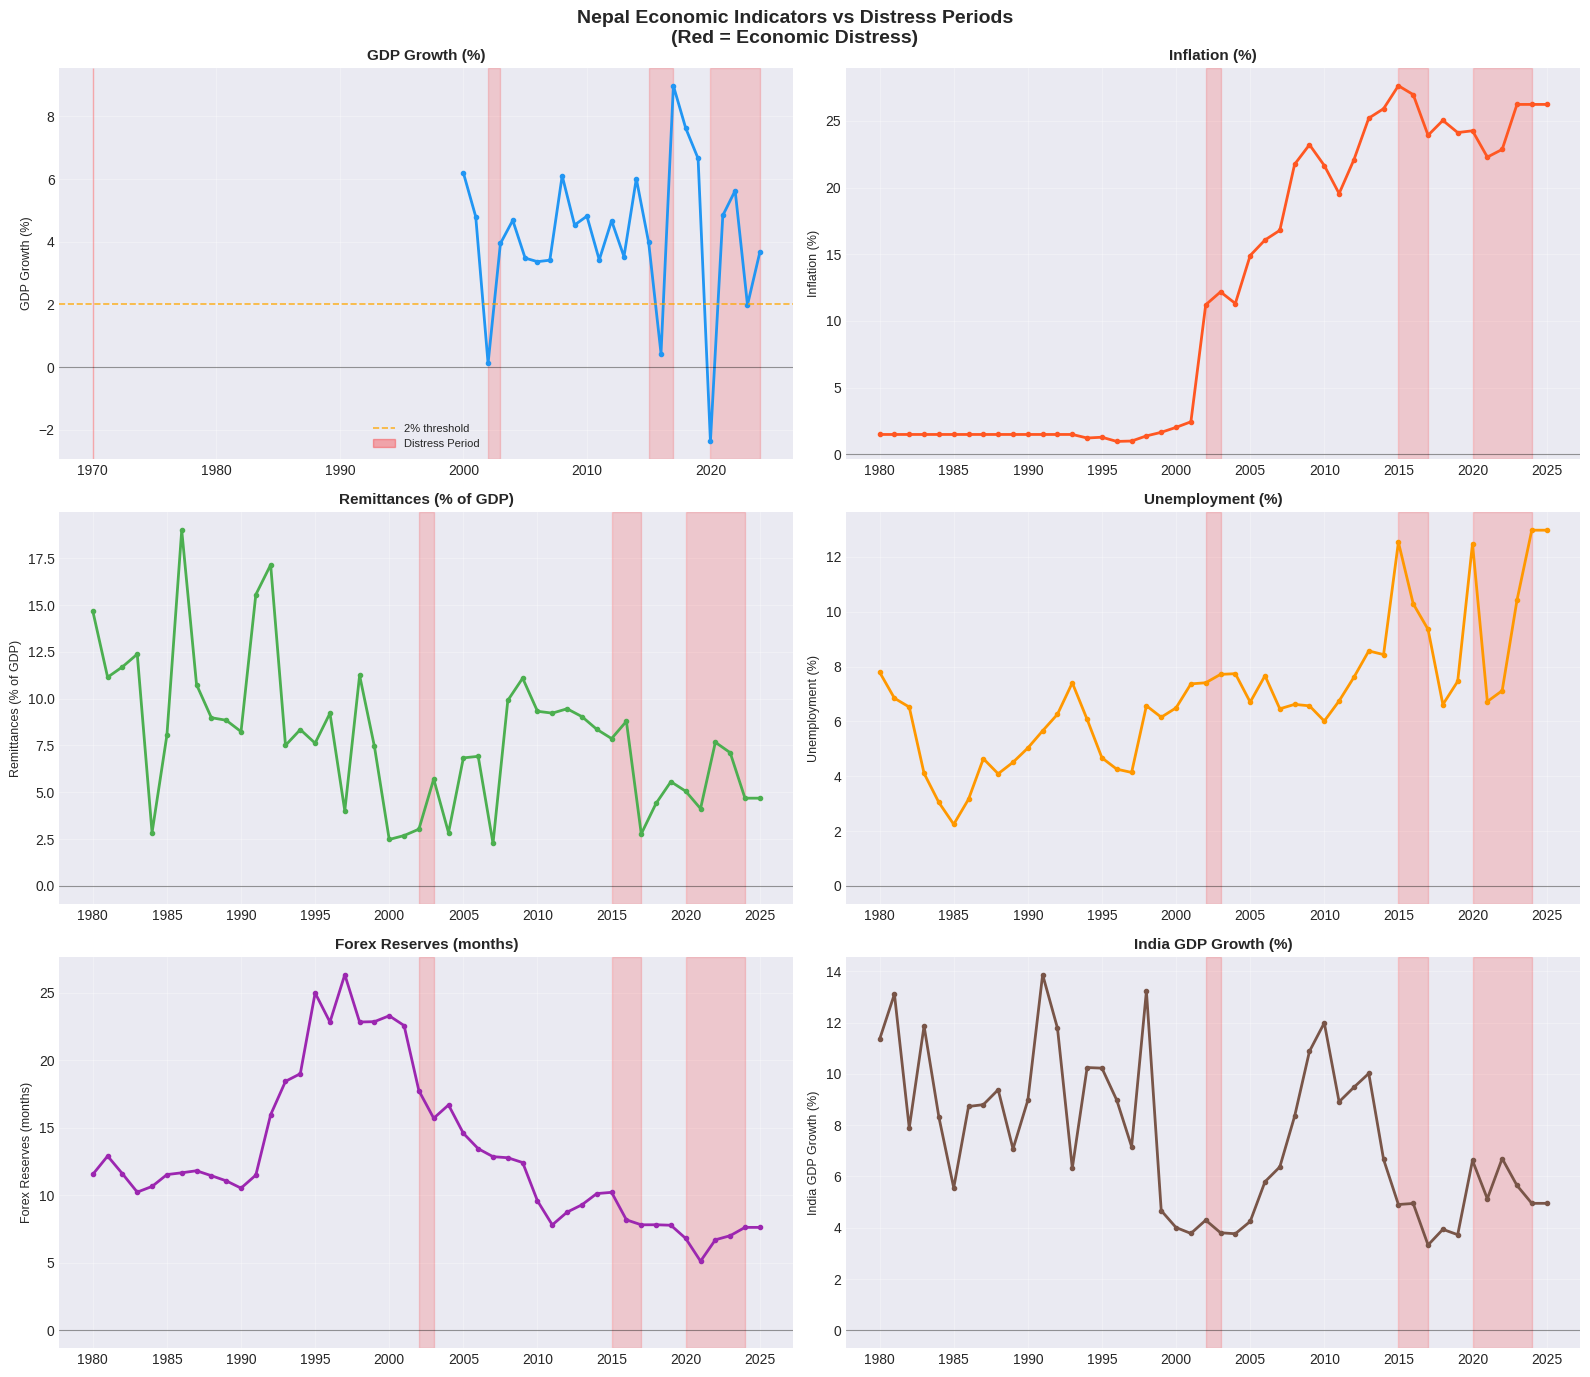

✅ Chart saved to outputs/week2_nepal_indicators.png


In [16]:
def shade_distress(ax):
    in_distress = False
    start = None
    for date, row in df_clean.iterrows():
        if row['distress'] == 1 and not in_distress:
            start = date
            in_distress = True
        elif row['distress'] == 0 and in_distress:
            ax.axvspan(start, date, alpha=0.15, color='red', label='_nolegend_')
            in_distress = False
    if in_distress:
        ax.axvspan(start, df_clean.index[-1], alpha=0.15, color='red')

PLOTS = [
    ('gdp_growth',            'GDP Growth (%)',          '#2196F3'),
    ('inflation',             'Inflation (%)',            '#FF5722'),
    ('remittances_pct_gdp',   'Remittances (% of GDP)',  '#4CAF50'),
    ('unemployment',          'Unemployment (%)',         '#FF9800'),
    ('forex_reserves_months', 'Forex Reserves (months)', '#9C27B0'),
    ('india_gdp_growth',      'India GDP Growth (%)',    '#795548'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(
    'Nepal Economic Indicators vs Distress Periods\n(Red = Economic Distress)',
    fontsize=14, fontweight='bold'
)

for ax, (col, label, color) in zip(axes.flatten(), PLOTS):
    if col not in df_clean.columns or df_clean[col].isna().all():
        ax.text(0.5, 0.5, f'{col}\nnot available',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        continue
    ax.plot(df_clean.index, df_clean[col],
            color=color, linewidth=2, marker='o', markersize=3)
    shade_distress(ax)
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.4)
    if col == 'gdp_growth':
        ax.axhline(y=2.0, color='orange', linewidth=1.2,
                  linestyle='--', alpha=0.8, label='2% threshold')
        ax.legend(fontsize=8)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

# Add one shared legend for distress shading
axes[0][0].axvspan(0, 0, alpha=0.3, color='red', label='Distress Period')
axes[0][0].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/week2_nepal_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/week2_nepal_indicators.png")

In [17]:
print(df_clean['distress'].mean())
print(df_clean[df_clean['distress']==1].index.year.tolist())

0.15217391304347827
[2002, 2015, 2016, 2020, 2021, 2022, 2023]


In [18]:
df_clean.to_csv('data/processed/nepal_macro_clean.csv')
print("✅ Final clean data saved!")
print(f"\n{'='*40}")
print("  WEEK 2 COMPLETE ✅")
print(f"{'='*40}")
print(f"  Years of data:   {len(df_clean)}")
print(f"  Features:        {len(df_clean.columns)-1}")
print(f"  Distress years:  {int(df_clean['distress'].sum())}")
print(f"  Normal years:    {int((df_clean['distress']==0).sum())}")
print(f"  Missing values:  {df_clean.isnull().sum().sum()}")
print(f"{'='*40}")

✅ Final clean data saved!

  WEEK 2 COMPLETE ✅
  Years of data:   46
  Features:        11
  Distress years:  7
  Normal years:    39
  Missing values:  21
